## EDA du jeu de données


## Import des librairies


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew


## Exploration des donnees


In [27]:
df = pd.read_csv("../data/Dataset.csv")
display(df)


,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


## Dimensions de donnees


In [28]:
print("Dimensions :", df.shape)
print("Nombre de lignes :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])


Dimensions : (300153, 12)
Nombre de lignes : 300153
Nombre de colonnes : 12


## Types et structure


In [29]:
df.info()
##df.types


<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  str    
 2   flight            300153 non-null  str    
 3   source_city       300153 non-null  str    
 4   departure_time    300153 non-null  str    
 5   stops             300153 non-null  str    
 6   arrival_time      300153 non-null  str    
 7   destination_city  300153 non-null  str    
 8   class             300153 non-null  str    
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), str(8)
memory usage: 27.5 MB


## Première observation


In [30]:
display(df.head())


,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


### Valeurs manquantes et doublons


In [31]:
print("Valeurs manquantes par colonne :")
print(df.isna().sum())
print("\nLignes dupliquées :", df.duplicated().sum())


Valeurs manquantes par colonne :
Unnamed: 0          0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

Lignes dupliquées : 0


### Statistiques descriptives


In [32]:
display(df.describe().round(2))
display(df.describe(exclude="number"))


,Unnamed: 0,duration,days_left,price
count,300153.00,300153.00,300153.00,300153.00
mean,150076.00,12.22,26.00,20889.66
std,86646.85,7.19,13.56,22697.77
min,0.00,0.83,1.00,1105.00
25%,75038.00,6.83,15.00,4783.00
50%,150076.00,11.25,26.00,7425.00
75%,225114.00,16.17,38.00,42521.00
max,300152.00,49.83,49.00,123071.00


,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class
count,300153,300153,300153,300153,300153,300153,300153,300153
unique,6,1561,6,6,3,6,6,2
top,Vistara,UK-706,Delhi,Morning,one,Night,Mumbai,Economy
freq,127859,3235,61343,71146,250863,91538,59097,206666


## Classification des variables


### Variables quantitatives (numériques)


In [33]:
numeric_col = [c for c in df.select_dtypes(include='number').columns.tolist() if c != 'Unnamed: 0']

print(numeric_col)
## Quantitatives : duration, days_left, price (cible)


['duration', 'days_left', 'price']


### Colonnes catégorielles


In [9]:
categorical_cols = ["airline", "source_city", "departure_time", "stops",
                    "arrival_time", "destination_city", "class"]
## Catégorielles : airline, source_city, departure_time, stops, arrival_time, destination_city, class


### Aperçu des sous-ensembles (catégorielles, ordinales, quantitatives)


In [34]:
categorical_df = df[["airline", "flight", "source_city", "destination_city", "class", "stops",
                    "arrival_time", "departure_time"]]
ordinal = df[["stops", "class"]]
quantitative = df[["duration", "days_left", "price"]]

print(categorical_df.head()) 
print(ordinal.head())
print(quantitative.head())
print(categorical_df.describe())
print(ordinal.describe())
print(quantitative.describe())


    airline   flight source_city destination_city    class stops  \
0  SpiceJet  SG-8709       Delhi           Mumbai  Economy  zero   
1  SpiceJet  SG-8157       Delhi           Mumbai  Economy  zero   
2   AirAsia   I5-764       Delhi           Mumbai  Economy  zero   
3   Vistara   UK-995       Delhi           Mumbai  Economy  zero   
4   Vistara   UK-963       Delhi           Mumbai  Economy  zero   

    arrival_time departure_time  
0          Night        Evening  
1        Morning  Early_Morning  
2  Early_Morning  Early_Morning  
3      Afternoon        Morning  
4        Morning        Morning  
  stops    class
0  zero  Economy
1  zero  Economy
2  zero  Economy
3  zero  Economy
4  zero  Economy
   duration  days_left  price
0      2.17          1   5953
1      2.33          1   5953
2      2.17          1   5956
3      2.25          1   5955
4      2.33          1   5955
        airline  flight source_city destination_city    class   stops  \
count    300153  300153      300

## Analyse technique des variables et listes de colonnes


In [35]:
numerical_cols = ["duration", "days_left", "price"]
categorical_cols = ["airline", "source_city", "departure_time", "stops",
                    "arrival_time", "destination_city", "class"]
ordinal_cols = ["stops", "class"] 


## Analyse univariée


### Variables catégorielles


In [36]:

for col in categorical_cols:
    vc = df[col].value_counts()
    vp = df[col].value_counts(normalize=True) * 100
    res = pd.DataFrame({"effectif": vc, "pourcentage": vp.round(2)})
    res = res.sort_values("effectif", ascending=False)
    print(f"=== {col} ===")
    display(res)


=== airline ===


,effectif,pourcentage
airline,,
Vistara,127859,42.60
Air_India,80892,26.95
Indigo,43120,14.37
GO_FIRST,23173,7.72
AirAsia,16098,5.36
SpiceJet,9011,3.00


=== source_city ===


,effectif,pourcentage
source_city,,
Delhi,61343,20.44
Mumbai,60896,20.29
Bangalore,52061,17.34
Kolkata,46347,15.44
Hyderabad,40806,13.60
Chennai,38700,12.89


=== departure_time ===


...

,effectif,pourcentage
arrival_time,,
Night,91538,30.50
Evening,78323,26.09
Morning,62735,20.90
Afternoon,38139,12.71
Early_Morning,15417,5.14
Late_Night,14001,4.66


=== destination_city ===


,effectif,pourcentage
destination_city,,
Mumbai,59097,19.69
Delhi,57360,19.11
Bangalore,51068,17.01
Kolkata,49534,16.50
Hyderabad,42726,14.23
Chennai,40368,13.45


=== class ===


,effectif,pourcentage
class,,
Economy,206666,68.85
Business,93487,31.15


**Observations — Tableaux de fréquence (variables catégorielles) :**
- airline : Vistara 42,6 % (127 859 vols), SpiceJet 3,0 % (9 011) ; ratio dominant/rare = 14,2.
- stops : one 83,6 % (250 863), two_or_more 4,4 % (13 286) ; ratio = 18,9.
- departure_time : Morning 23,7 % (71 146), Late_Night 0,4 % (1 306) ; ratio = 54,5.
- arrival_time : Night 30,5 % (91 538), Late_Night 4,7 % (14 001) ; ratio = 6,5.
- source_city : Delhi 20,4 % (61 343), Chennai 12,9 % (38 700) ; ratio = 1,6 ; destination_city : Mumbai 19,7 % (59 097), Chennai 13,4 % (40 368) ; ratio = 1,5.
- class : Economy 68,9 % (206 666), Business 31,1 % (93 487) ; ratio = 2,2.


### Répartitions (barres)


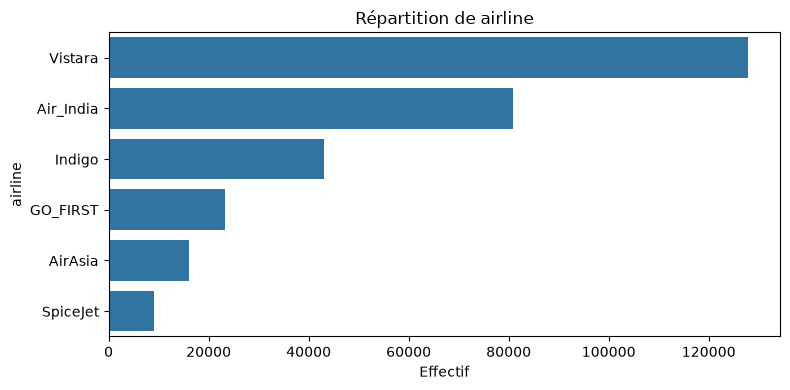

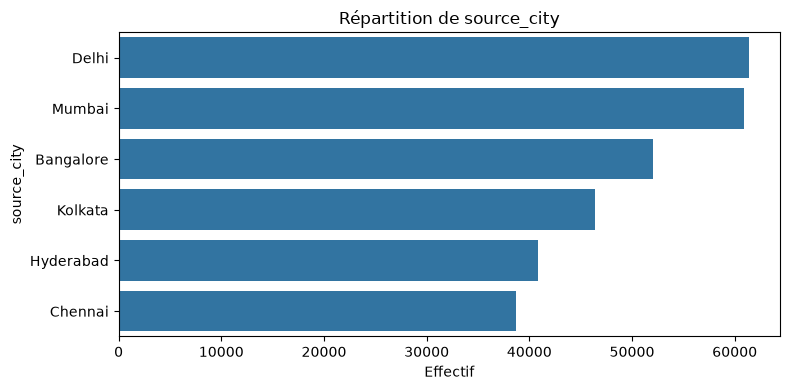

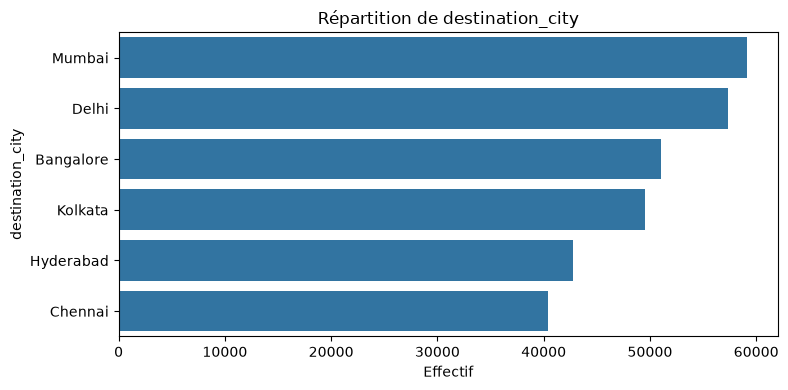

In [37]:

nominal_cols = ["airline", "source_city", "destination_city"]
for col in nominal_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, y=col, order=df[col].value_counts().index)
    plt.title(f"Répartition de {col}")
    plt.xlabel("Effectif")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


**Observations — Répartition par ville et par compagnie (barres horizontales) :**
- airline : Vistara 42,6 % en tête (127 859 vols), SpiceJet 3,0 % en queue (9 011) ; ratio = 14,2.
- airline : AirAsia, GO_FIRST, Indigo et SpiceJet = 100 % Economy (aucun vol Business) ; Air_India = 40,7 % Business, Vistara = 47,4 % Business.
- source_city : Delhi 20,4 % (61 343) dominant, Chennai 12,9 % (38 700) ; ratio = 1,6.
- destination_city : Mumbai 19,7 % (59 097) dominant, Chennai 13,4 % (40 368) ; ratio = 1,5.
- Prix médian par ville : source Kolkata 7 958 vs Delhi 6 840 (écart 1 118) ; destination Chennai 7 900 vs Delhi 6 521 (écart 1 379).


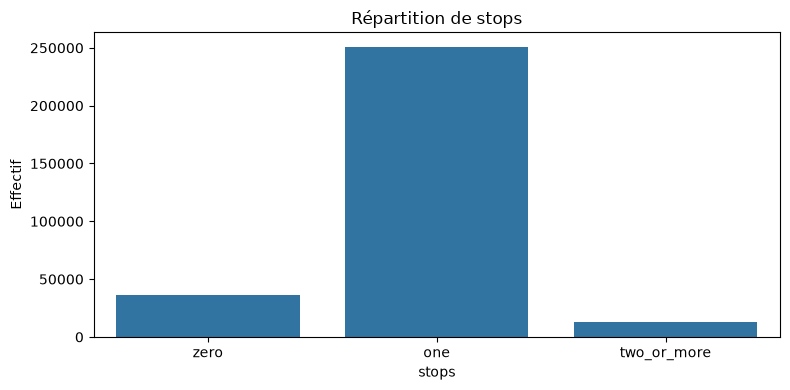

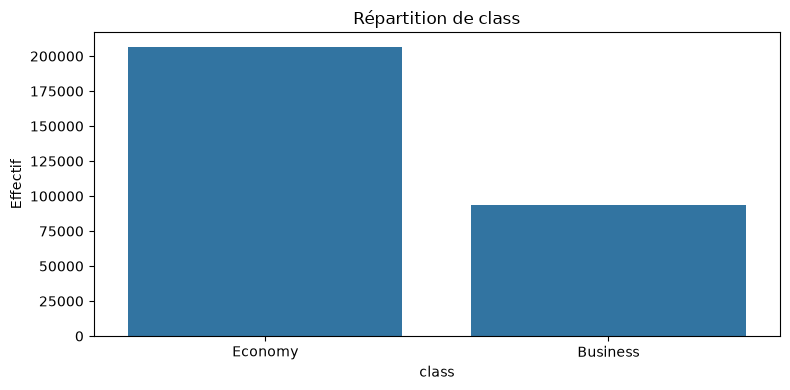

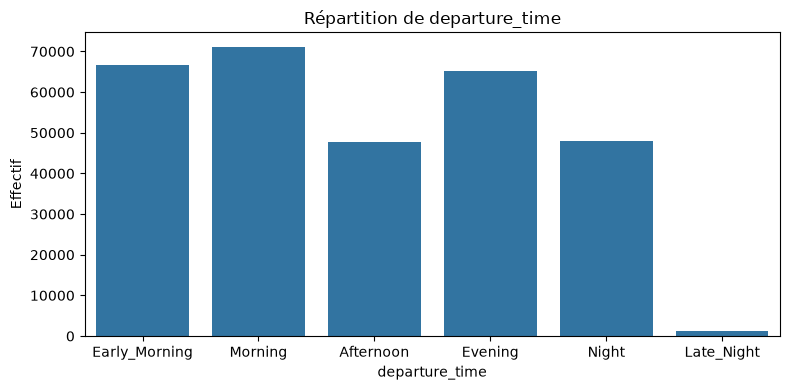

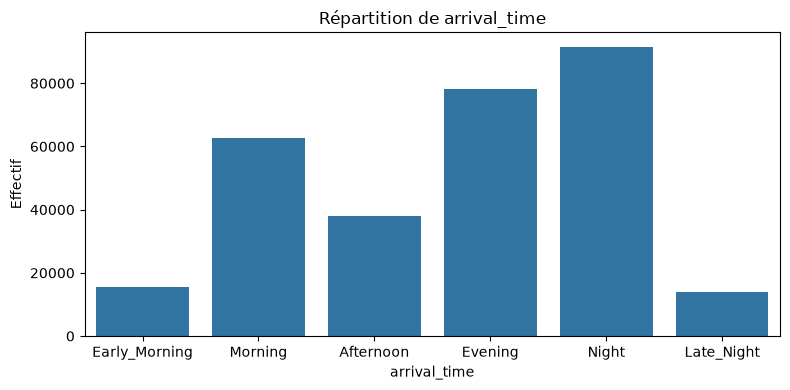

In [38]:

orders = {
  "stops": ["zero", "one", "two_or_more"],
  "class": ["Economy", "Business"],
  "departure_time": ["Early_Morning", "Morning", "Afternoon", "Evening", "Night", "Late_Night"],
  "arrival_time": ["Early_Morning", "Morning", "Afternoon", "Evening", "Night", "Late_Night"],
}
for col in ["stops", "class", "departure_time", "arrival_time"]:
    plt.figure(figsize=(8,4))
    order = orders.get(col, df[col].value_counts().index)
    sns.countplot(data=df, x=col, order=order)
    plt.title(f"Répartition de {col}")
    plt.xlabel(col)
    plt.ylabel("Effectif")
    plt.tight_layout()
    plt.show()


**Observations — Répartition par escale, classe et créneau horaire 
- class : Economy 206 666 (68,9 %), Business 93 487 (31,1 %) ; ratio = 2,2.
- stops : one 250 863 (83,6 %) vs two_or_more 13 286 (4,4 %) ; ratio = 18,9 ; part Business = zero 22,5 %, one 33,6 %, 

### Catégories dominantes


In [39]:

lignes = []
for col in categorical_cols:
    p = df[col].value_counts(normalize=True)*100
    lignes.append({
        "variable": col,
        "nb_modalites": int(p.size),
        "dominante": p.idxmax(),
        "part_dominante_%": round(float(p.max()), 2),
        "plus_rare": p.idxmin(),
        "part_rare_%": round(float(p.min()), 2),
    })
dom = pd.DataFrame(lignes).set_index("variable")
display(dom)


,nb_modalites,dominante,part_dominante_%,plus_rare,part_rare_%
variable,,,,,
airline,6,Vistara,42.60,SpiceJet,3.00
source_city,6,Delhi,20.44,Chennai,12.89
departure_time,6,Morning,23.70,Late_Night,0.44
stops,3,one,83.58,two_or_more,4.43
arrival_time,6,Night,30.50,Late_Night,4.66
destination_city,6,Mumbai,19.69,Chennai,13.45
class,2,Economy,68.85,Business,31.15


**Observations — Catégories dominantes :**
- airline : dominante Vistara 42,6 % ; plus rare SpiceJet 3,0 % (ratio 14,2).
- departure_time : dominante Morning 23,7 % ; plus rare Late_Night 0,4 % (ratio 54,5).
- arrival_time : dominante Night 30,5 % ; plus rare Late_Night 4,7 % (ratio 6,5).
- class : Economy 68,9 % vs Business 31,1 % (ratio 2,2) ; source_city Delhi 20,4 % vs Chennai 12,9 % ; destination_city Mumbai 19,7 % vs Chennai 13,4 %.


### Déséquilibres


In [40]:

lignes = []
for col in categorical_cols:
    p = df[col].value_counts(normalize=True)*100
    ratio = p.max() / p.min() if p.min() > 0 else float('inf')
    if ratio < 2:
        qual = "faible (< 2)"
    elif ratio < 10:
        qual = "modéré (>=2 et < 10)"
    else:
        qual = "fort (>= 10)"
    lignes.append({
        "variable": col,
        "part_dominante_%": round(float(p.max()), 2),
        "part_rare_%": round(float(p.min()), 2),
        "ratio_dom_rare": round(float(ratio), 2),
        "qualification": qual,
    })
bal = pd.DataFrame(lignes).set_index("variable")
display(bal)


,part_dominante_%,part_rare_%,ratio_dom_rare,qualification
variable,,,,
airline,42.60,3.00,14.19,fort (>= 10)
source_city,20.44,12.89,1.59,faible (< 2)
departure_time,23.70,0.44,54.48,fort (>= 10)
stops,83.58,4.43,18.88,fort (>= 10)
arrival_time,30.50,4.66,6.54,modéré (>=2 et < 10)
destination_city,19.69,13.45,1.46,faible (< 2)
class,68.85,31.15,2.21,modéré (>=2 et < 10)


**Observations — Déséquilibres (ratio dominant/rare) :**
- ratio < 2 : source_city 1,59, destination_city 1,46 (déséquilibre faible).



### Variables quantitatives


### Statistiques descriptives


In [42]:

res_list = []
for col in numerical_cols:
    s = df[col].describe()
    serie = df[col]
    var = serie.var(ddof=1)
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    cv = (serie.std(ddof=1) / serie.mean()) if serie.mean() != 0 else float('nan')
    res_list.append({
        "variable": col,
        "count": int(s["count"]),
        "mean": round(float(s["mean"]), 4),
        "std": round(float(s["std"]), 4),
        "min": round(float(s["min"]), 4),
        "25%": round(float(s["25%"]), 4),
        "50%": round(float(s["50%"]), 4),
        "75%": round(float(s["75%"]), 4),
        "max": round(float(s["max"]), 4),
        "variance": round(float(var), 4),
        "IQR": round(float(iqr), 4),
        "CV": round(float(cv), 4),
    })
stats_q = pd.DataFrame(res_list).set_index("variable")
display(stats_q)


,count,mean,std,min,25%,50%,75%,max,variance,IQR,CV
variable,,,,,,,,,,,
duration,300153,12.2210,7.1920,0.83,6.83,11.25,16.17,49.83,5.172480e+01,9.34,0.5885
days_left,300153,26.0048,13.5610,1.00,15.00,26.00,38.00,49.00,1.839008e+02,23.00,0.5215
price,300153,20889.6605,22697.7674,1105.00,4783.00,7425.00,42521.00,123071.00,5.151886e+08,37738.00,1.0866


**Observations — Statistiques descriptives (variables quantitatives) :**
- price : moyenne 20 889,66, écart-type 22 697,77 (CV 1,09), min 1 105, max 123 071.
- duration : moyenne 12,22, écart-type 7,19 (CV 0,59), min 0,83, max 49,83.
- days_left : moyenne 26,00, écart-type 13,56 (CV 0,52), min 1, max 49.


### Distributions


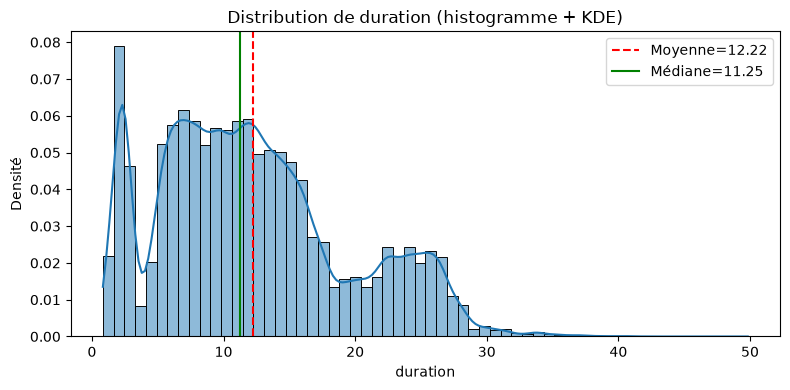

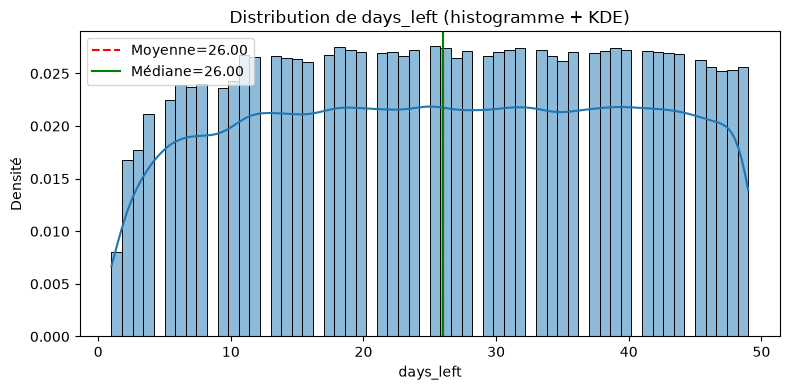

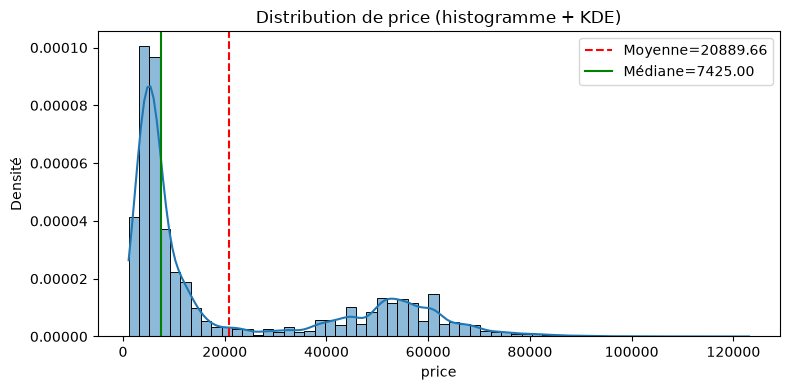

In [43]:

for col in numerical_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True, bins=60, stat="density")
    m = df[col].mean()
    med = df[col].median()
    plt.axvline(m, color='red', linestyle='--', label=f'Moyenne={m:.2f}')
    plt.axvline(med, color='green', linestyle='-', label=f'Médiane={med:.2f}')
    plt.legend()
    plt.title(f"Distribution de {col} (histogramme + KDE)")
    plt.xlabel(col)
    plt.ylabel("Densité")
    plt.tight_layout()
    plt.show()


**Observations — Distributions de duration, days_left et price (histogrammes + KDE) :**
- duration : moyenne 12,22 vs médiane 11,25 (écart +0,97) ; skew 0,60 ; pic principal vers 2 h ; queue à droite (max 49,83 h).
- days_left : moyenne 26,00 vs médiane 26,00 (écart 0,00) ; skew −0,04 ; distribution quasi uniforme de 1 à 49 jours.
- price : moyenne 20 889,66 vs médiane 7 425 (écart +13 464,66) ; skew 1,06 ; min 1 105, max 123 071 ; deux masses (pic bas ~4 150, cluster haut ~45 000–61 000).


### Valeurs extremes (outliers)


,q1,q3,IQR,borne_inf_Tukey,borne_sup_Tukey,nb_outliers_inf,nb_outliers_sup,nb_outliers_total,%_outliers
variable,,,,,,,,,
duration,6.83,16.17,9.34,-7.18,30.18,0,2110,2110,0.703
days_left,15.00,38.00,23.00,-19.50,72.50,0,0,0,0.000
price,4783.00,42521.00,37738.00,-51824.00,99128.00,0,123,123,0.041


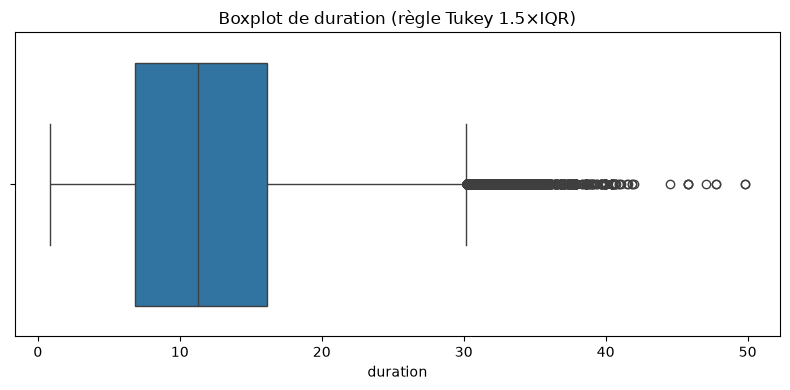

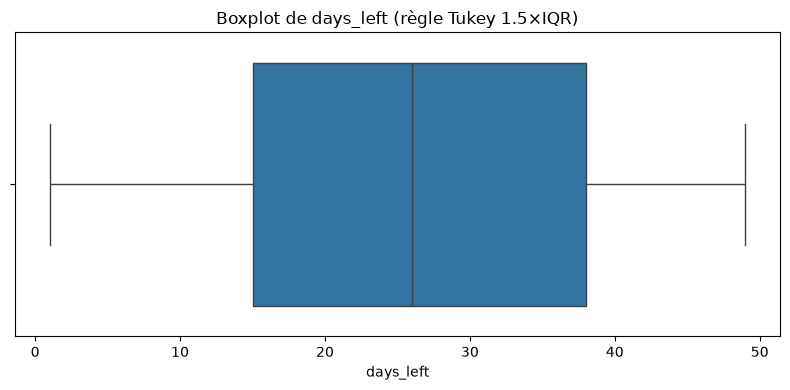

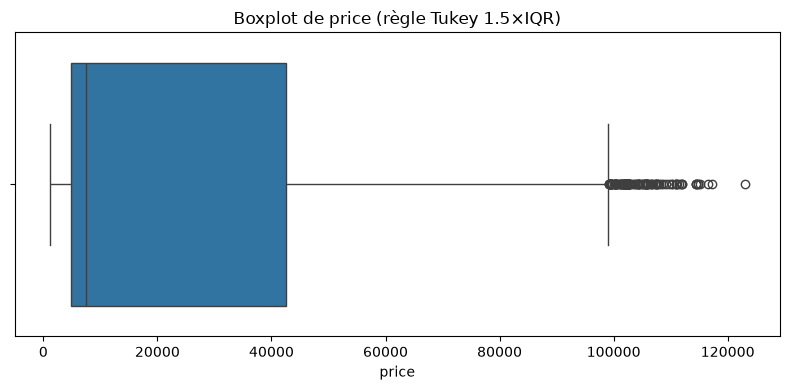

In [44]:

out_rows = []
for col in numerical_cols:
    s = df[col]
    q1 = s.quantile(0.25); q3 = s.quantile(0.75); iqr = q3-q1
    inf = q1 - 1.5*iqr; sup = q3 + 1.5*iqr
    n_low = (s < inf).sum(); n_high = (s > sup).sum(); n_tot = n_low + n_high
    out_rows.append({
        "variable": col,
        "q1": round(float(q1),4),
        "q3": round(float(q3),4),
        "IQR": round(float(iqr),4),
        "borne_inf_Tukey": round(float(inf),4),
        "borne_sup_Tukey": round(float(sup),4),
        "nb_outliers_inf": int(n_low),
        "nb_outliers_sup": int(n_high),
        "nb_outliers_total": int(n_tot),
        "%_outliers": round(float(100*n_tot/len(df)), 4) if len(df)>0 else 0
    })
out_df = pd.DataFrame(out_rows).set_index("variable")
display(out_df)

# Boxplots
for col in numerical_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=df, x=col)
    plt.title(f"Boxplot de {col} (règle Tukey 1.5×IQR)")
    plt.tight_layout()
    plt.show()


**Observations — Boxplots de duration, days_left et price (règle Tukey 1,5×IQR) :**
- duration : Q1 6,83 / médiane 11,25 / Q3 16,17 ; whisker supérieur 30,18 ; 0 point bas, 2 110 hauts (0,70 %).
- days_left : Q1 15 / médiane 26 / Q3 38 ; whiskers sur toute l'étendue 1–49 ; 0 valeur hors bornes Tukey.
- price : Q1 4 783 / médiane 7 425 / Q3 42 521 (IQR 37 738) ; whisker supérieur 99 128 ; 0 point bas, 123 hauts (0,04 %).


### Asymétrie


In [45]:

from scipy.stats import skew
sk_list = []
for col in numerical_cols:
    skv = skew(df[col], nan_policy='omit')
    if skv > 0.1:
        comm = "asymetrie a droite (positive)"
    elif skv < -0.1:
        comm = "asymetrie a gauche (negative)"
    else:
        comm = "proche de symetrique "
    sk_list.append({
        "variable": col,
        "skewness": round(float(skv), 4),
        "commentaire": comm
    })
sk_df = pd.DataFrame(sk_list).set_index("variable")
display(sk_df)


,skewness,commentaire
variable,,
duration,0.6029,asymetrie a droite (positive)
days_left,-0.0355,proche de symetrique
price,1.0614,asymetrie a droite (positive)


**Observations — Asymétrie (skewness) :**
- price : skew = 1,06.
- duration : skew = 0,60.
- days_left : skew = −0,04.


##  Analyse multivariee

Pour chaque relation, trois vues côte à côte : agrégation en barres, distribution des points, boxplot — colorés par classe (hue="class") quand pertinent. Les statistiques sont toujours calculées sur l'intégralité des données (l'échantillon de 5 000 points ne sert qu'à la lisibilité du scatter/stripplot).


### Durée du vol et prix (duration vs price)


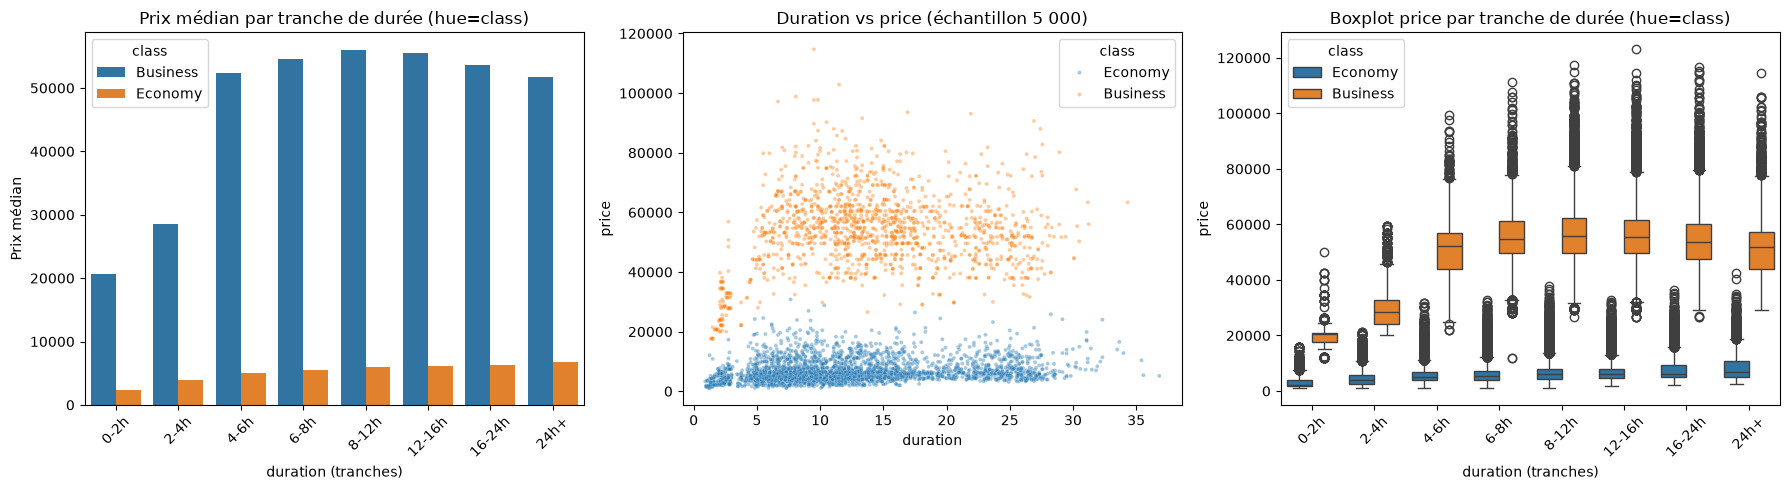

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dur_bin = pd.cut(df["duration"], bins=[0, 2, 4, 6, 8, 12, 16, 24, 50],
                 labels=["0-2h", "2-4h", "4-6h", "6-8h", "8-12h", "12-16h", "16-24h", "24h+"])
agg = df.assign(dur_bin=dur_bin).groupby(["dur_bin", "class"], observed=True)["price"].median().reset_index()
sample = df.sample(5000, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=agg, x="dur_bin", y="price", hue="class", ax=axes[0])
axes[0].set_title("Prix médian par tranche de durée (hue=class)")
axes[0].set_xlabel("duration (tranches)")
axes[0].set_ylabel("Prix médian")
axes[0].tick_params(axis="x", rotation=45)

sns.scatterplot(data=sample, x="duration", y="price", hue="class", alpha=0.4, s=8, ax=axes[1])
axes[1].set_title("Duration vs price (échantillon 5 000)")
axes[1].set_xlabel("duration")
axes[1].set_ylabel("price")

sns.boxplot(data=df.assign(dur_bin=dur_bin), x="dur_bin", y="price", hue="class", ax=axes[2])
axes[2].set_title("Boxplot price par tranche de durée (hue=class)")
axes[2].set_xlabel("duration (tranches)")
axes[2].set_ylabel("price")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


In [47]:

r_glob = df["duration"].corr(df["price"])
r_eco = df.loc[df["class"] == "Economy", ["duration", "price"]].corr().iloc[0, 1]
r_bus = df.loc[df["class"] == "Business", ["duration", "price"]].corr().iloc[0, 1]
print(f"Corrélation de Pearson (globale) duration-price : {r_glob:.4f}")
print(f"Corrélation de Pearson duration-price (Economy) : {r_eco:.4f}")
print(f"Corrélation de Pearson duration-price (Business) : {r_bus:.4f}")

dur_bin = pd.cut(df["duration"], bins=[0, 2, 4, 6, 8, 12, 16, 24, 50],
                 labels=["0-2h", "2-4h", "4-6h", "6-8h", "8-12h", "12-16h", "16-24h", "24h+"])
res = df.assign(dur_bin=dur_bin)
print("\nPrix médian par tranche de durée (toutes classes) :")
print(res.groupby("dur_bin", observed=True)["price"].median().round(0))
print("\nPrix médian par tranche de durée et par classe :")
print(res.groupby(["dur_bin", "class"], observed=True)["price"].median().round(0).unstack())
print("\nEffectifs par tranche de durée et par classe :")
print(res.groupby(["dur_bin", "class"], observed=True).size().unstack())


Corrélation de Pearson (globale) duration-price : 0.2042
Corrélation de Pearson duration-price (Economy) : 0.2884
Corrélation de Pearson duration-price (Business) : 0.2427

Prix médian par tranche de durée (toutes classes) :
dur_bin
0-2h       3000.0
2-4h       4502.0
4-6h       5728.0
6-8h       6323.0
8-12h      7484.0
12-16h    10744.0
16-24h    12045.0
24h+      10826.0
Name: price, dtype: float64

Prix médian par tranche de durée et par classe :
class    Business  Economy
dur_bin                   
0-2h      20684.0   2309.0
2-4h      28510.0   4001.0
4-6h      52287.0   5017.0
6-8h      54608.0   5549.0
8-12h     55983.0   5954.0
12-16h    55502.0   6109.0
16-24h    53645.0   6275.0
24h+      51707.0   6726.0

Effectifs par tranche de durée et par classe :
class    Business  Economy
dur_bin                   
0-2h         1608     8788
2-4h         6713    20631
4-6h         4121    19316
6-8h         7710    27687
8-12h       19236    48118
12-16h      24126    35799
16-24h     

**Observations — Durée du vol et prix (duration vs price) :**
- r de Pearson duration-price : global 0,2042 ; Economy 0,2884 ; Business 0,2427.
- Prix médian par tranche de durée : 0-2h = 3 000 ; 16-24h = 12 045 ; 24h+ = 10 826 (le maximum de médiane est à 16-24h, pas à la durée maximale).
- Médiane Economy : 2 309 (0-2h) → 6 726 (24h+) ; médiane Business : 20 684 (0-2h) → 55 983 (8-12h), puis 51 707 (24h+).
- Tranches les plus volumineuses : 8-12h (67 354 vols) et 12-16h (59 925 vols).


### Compagnie aérienne et prix (airline vs price)


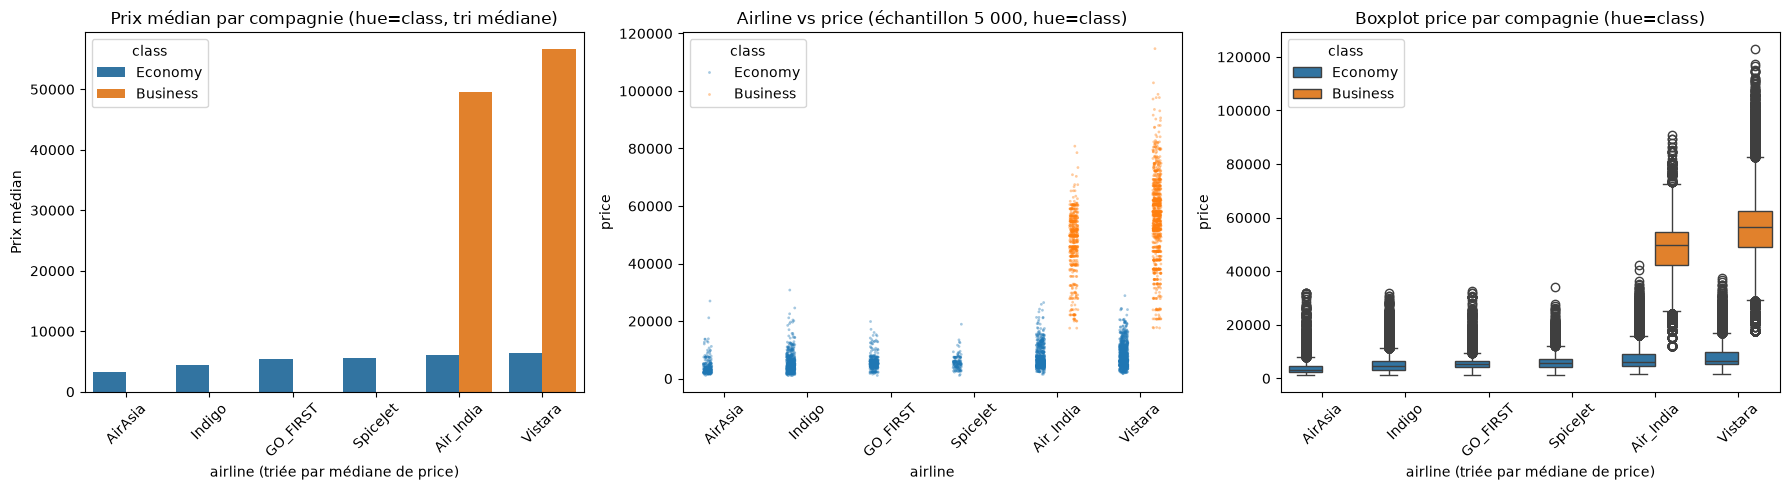

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

air_order = df.groupby("airline")["price"].median().sort_values().index.tolist()
agg = df.groupby(["airline", "class"], observed=True)["price"].median().reset_index()
sample = df.sample(5000, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=agg, x="airline", y="price", hue="class", order=air_order, ax=axes[0])
axes[0].set_title("Prix médian par compagnie (hue=class, tri médiane)")
axes[0].set_xlabel("airline (triée par médiane de price)")
axes[0].set_ylabel("Prix médian")
axes[0].tick_params(axis="x", rotation=45)

sns.stripplot(data=sample, x="airline", y="price", hue="class", order=air_order,
              dodge=True, alpha=0.4, s=2, ax=axes[1])
axes[1].set_title("Airline vs price (échantillon 5 000, hue=class)")
axes[1].set_xlabel("airline")
axes[1].set_ylabel("price")
axes[1].tick_params(axis="x", rotation=45)

sns.boxplot(data=df, x="airline", y="price", hue="class", order=air_order, ax=axes[2])
axes[2].set_title("Boxplot price par compagnie (hue=class)")
axes[2].set_xlabel("airline (triée par médiane de price)")
axes[2].set_ylabel("price")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


In [49]:

print("Médiane de price par compagnie (croissante) :")
print(df.groupby("airline")["price"].median().round(0).sort_values())
print("\nMédiane de price par compagnie et par classe :")
print(df.groupby(["airline", "class"], observed=True)["price"].median().round(0).unstack())
print("\nEffectifs par compagnie et par classe :")
print(df.groupby(["airline", "class"], observed=True).size().unstack())


Médiane de price par compagnie (croissante) :
airline
AirAsia       3276.0
Indigo        4453.0
GO_FIRST      5336.0
SpiceJet      5654.0
Air_India    11520.0
Vistara      15543.0
Name: price, dtype: float64

Médiane de price par compagnie et par classe :
class      Business  Economy
airline                     
AirAsia         NaN   3276.0
Air_India   49613.0   6082.0
GO_FIRST        NaN   5336.0
Indigo          NaN   4453.0
SpiceJet        NaN   5654.0
Vistara     56588.0   6461.0

Effectifs par compagnie et par classe :
class      Business  Economy
airline                     
AirAsia         NaN  16098.0
Air_India   32898.0  47994.0
GO_FIRST        NaN  23173.0
Indigo          NaN  43120.0
SpiceJet        NaN   9011.0
Vistara     60589.0  67270.0


**Observations — Compagnie aérienne et prix (airline vs price) :**
- Médiane de price par compagnie (croissant) : AirAsia 3 276 → Indigo 4 453 → GO_FIRST 5 336 → SpiceJet 5 654 → Air_India 11 520 → Vistara 15 543 (×4,7 entre la moins et la plus chère).
- Business absent chez AirAsia, Indigo, GO_FIRST et SpiceJet (0 vol) ; présent chez Air_India (32 898 vols) et Vistara (60 589 vols).
- Médiane Economy : AirAsia 3 276 vs Vistara 6 461 (écart 3 185) ; médiane Business : Air_India 49 613 vs Vistara 56 588 (écart 6 975).
- Air_India et Vistara, seules compagnies avec les 2 classes, ont les deux médianes globales les plus hautes (11 520 et 15 543).


### Nombre d'escales et prix (stops vs price)


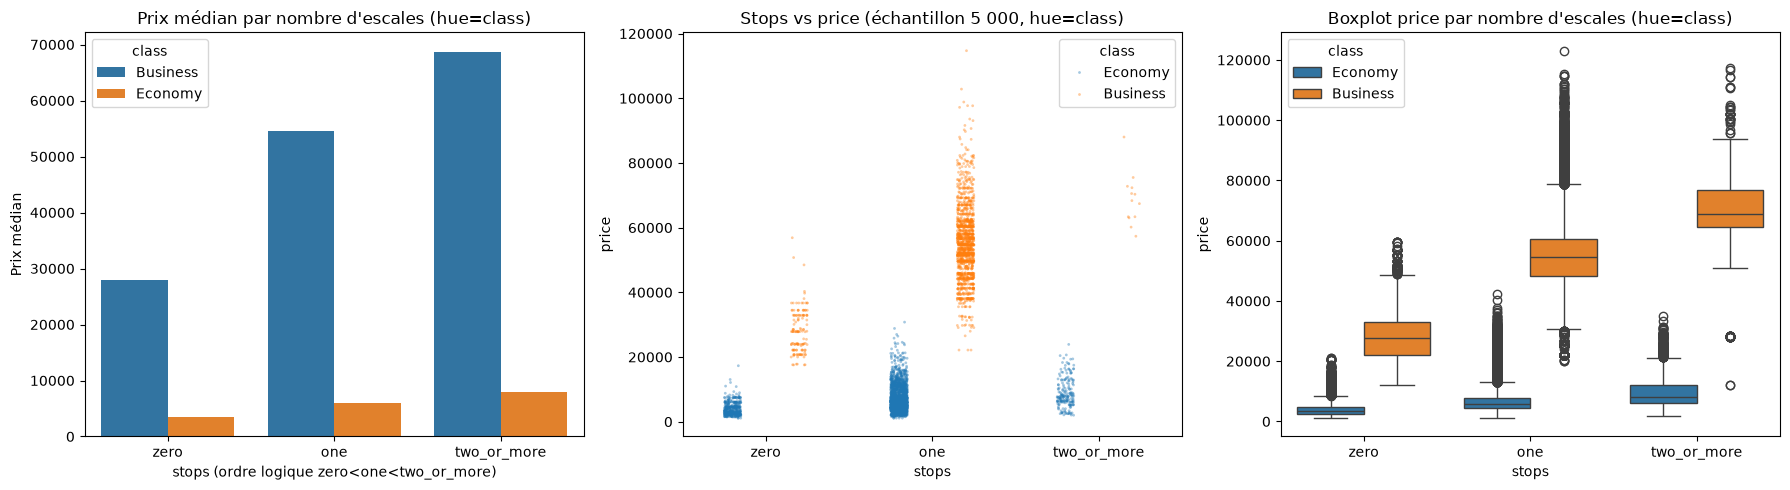

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

stop_order = ["zero", "one", "two_or_more"]
agg = df.groupby(["stops", "class"], observed=True)["price"].median().reset_index()
sample = df.sample(5000, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=agg, x="stops", y="price", hue="class", order=stop_order, ax=axes[0])
axes[0].set_title("Prix médian par nombre d'escales (hue=class)")
axes[0].set_xlabel("stops (ordre logique zero<one<two_or_more)")
axes[0].set_ylabel("Prix médian")

sns.stripplot(data=sample, x="stops", y="price", hue="class", order=stop_order,
              dodge=True, alpha=0.4, s=2, ax=axes[1])
axes[1].set_title("Stops vs price (échantillon 5 000, hue=class)")
axes[1].set_xlabel("stops")
axes[1].set_ylabel("price")

sns.boxplot(data=df, x="stops", y="price", hue="class", order=stop_order, ax=axes[2])
axes[2].set_title("Boxplot price par nombre d'escales (hue=class)")
axes[2].set_xlabel("stops")
axes[2].set_ylabel("price")

plt.tight_layout()
plt.show()


In [51]:

print("Médiane et moyenne de price par nombre d'escales :")
print(df.groupby("stops")["price"].agg(["median", "mean"]).round(0))
print("\nMédiane de price par escale et par classe :")
print(df.groupby(["stops", "class"], observed=True)["price"].median().round(0).unstack())
print("\nEffectifs par escale et par classe :")
print(df.groupby(["stops", "class"], observed=True).size().unstack())


Médiane et moyenne de price par nombre d'escales :
             median     mean
stops                       
one          7959.0  22901.0
two_or_more  8307.0  14113.0
zero         4499.0   9376.0

Médiane de price par escale et par classe :
class        Business  Economy
stops                         
one           54608.0   5937.0
two_or_more   68743.0   8012.0
zero          27864.0   3531.0

Effectifs par escale et par classe :
class        Business  Economy
stops                         
one             84302   166561
two_or_more      1083    12203
zero             8102    27902


**Observations — Nombre d'escales et prix (stops vs price) :**
- Médiane de price : zero = 4 499 ; one = 7 959 ; two_or_more = 8 307 (×1,85 entre zero et two_or_more).
- Par classe : Economy 3 531 → 5 937 → 8 012 ; Business 27 864 → 54 608 → 68 743 (zero → two_or_more).
- two_or_more ne contient que 1 083 vols Business (8,2 % de la catégorie) vs zero 22,5 % et one 33,6 %.
- two_or_more est la catégorie la plus rare (13 286 vols, 4,4 %).


### Nombre de jours avant le vol et prix (days_left vs price)


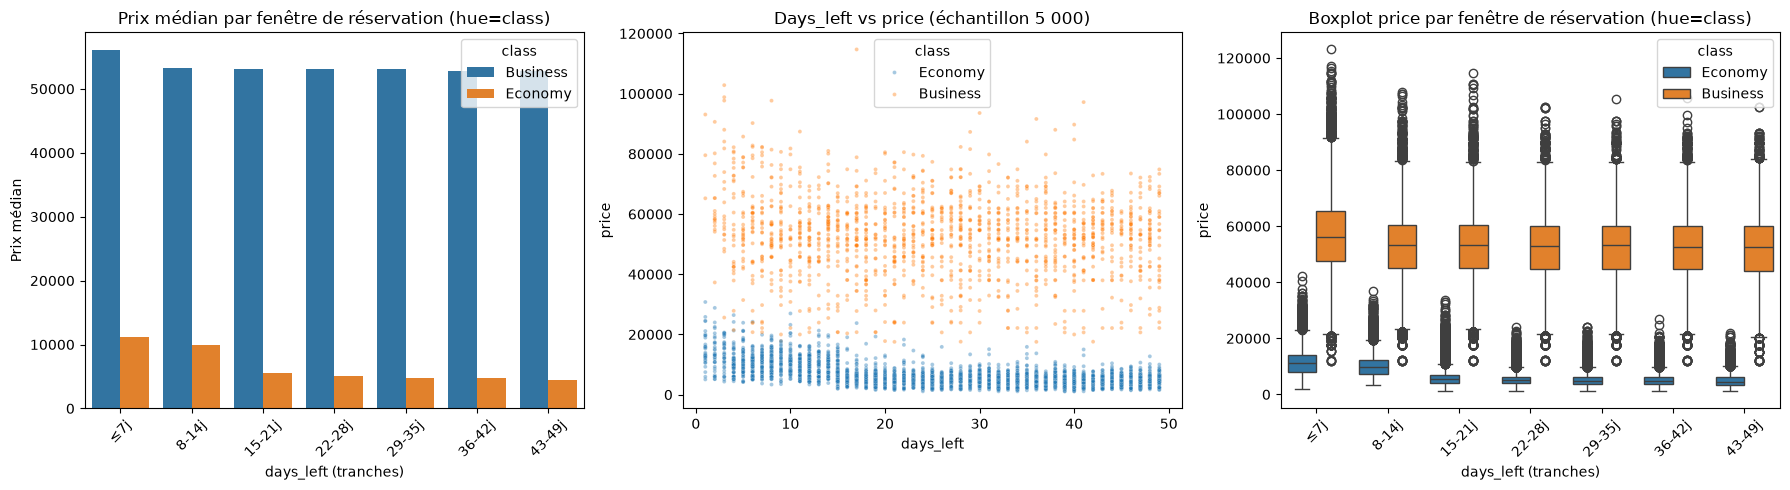

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dl_bin = pd.cut(df["days_left"], bins=[0, 7, 14, 21, 28, 35, 42, 50],
                labels=["≤7j", "8-14j", "15-21j", "22-28j", "29-35j", "36-42j", "43-49j"])
agg = df.assign(dl_bin=dl_bin).groupby(["dl_bin", "class"], observed=True)["price"].median().reset_index()
sample = df.sample(5000, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=agg, x="dl_bin", y="price", hue="class", ax=axes[0])
axes[0].set_title("Prix médian par fenêtre de réservation (hue=class)")
axes[0].set_xlabel("days_left (tranches)")
axes[0].set_ylabel("Prix médian")
axes[0].tick_params(axis="x", rotation=45)

sns.scatterplot(data=sample, x="days_left", y="price", hue="class", alpha=0.4, s=8, ax=axes[1])
axes[1].set_title("Days_left vs price (échantillon 5 000)")
axes[1].set_xlabel("days_left")
axes[1].set_ylabel("price")

sns.boxplot(data=df.assign(dl_bin=dl_bin), x="dl_bin", y="price", hue="class", ax=axes[2])
axes[2].set_title("Boxplot price par fenêtre de réservation (hue=class)")
axes[2].set_xlabel("days_left (tranches)")
axes[2].set_ylabel("price")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


In [53]:

r_glob = df["days_left"].corr(df["price"])
r_eco = df.loc[df["class"] == "Economy", ["days_left", "price"]].corr().iloc[0, 1]
r_bus = df.loc[df["class"] == "Business", ["days_left", "price"]].corr().iloc[0, 1]
print(f"Corrélation de Pearson (globale) days_left-price : {r_glob:.4f}")
print(f"Corrélation de Pearson days_left-price (Economy) : {r_eco:.4f}")
print(f"Corrélation de Pearson days_left-price (Business) : {r_bus:.4f}")

dl_bin = pd.cut(df["days_left"], bins=[0, 7, 14, 21, 28, 35, 42, 50],
                labels=["≤7j", "8-14j", "15-21j", "22-28j", "29-35j", "36-42j", "43-49j"])
res = df.assign(dl_bin=dl_bin)
print("\nPrix median par fenetre de reservation (toutes classes) :")
print(res.groupby("dl_bin", observed=True)["price"].median().round(0))
print("\nPrix médian par fenêtre de réservation et par classe :")
print(res.groupby(["dl_bin", "class"], observed=True)["price"].median().round(0).unstack())
print("\nEffectifs par fenêtre de réservation et par classe :")
print(res.groupby(["dl_bin", "class"], observed=True).size().unstack())


Corrélation de Pearson (globale) days_left-price : -0.0919
Corrélation de Pearson days_left-price (Economy) : -0.5596
Corrélation de Pearson days_left-price (Business) : -0.0913

Prix median par fenetre de reservation (toutes classes) :
dl_bin
≤7j       13944.0
8-14j     12118.0
15-21j     6590.0
22-28j     6132.0
29-35j     6082.0
36-42j     6067.0
43-49j     5949.0
Name: price, dtype: float64

Prix médian par fenêtre de réservation et par classe :
class   Business  Economy
dl_bin                   
≤7j      56040.0  11248.0
8-14j    53209.0   9945.0
15-21j   53164.0   5499.0
22-28j   53071.0   5092.0
29-35j   53152.0   4827.0
36-42j   52715.0   4792.0
43-49j   52715.0   4502.0

Effectifs par fenêtre de réservation et par classe :
class   Business  Economy
dl_bin                   
≤7j        10548    21565
8-14j      13772    29033
15-21j     13846    31305
22-28j     14021    31504
29-35j     13916    31336
36-42j     14025    31599
43-49j     13359    30324


**Observations — Nombre de jours avant le vol et prix (days_left vs price) :**
- r de Pearson days_left-price : global −0,09 ; Economy −0,56 ; Business −0,09.
- Médiane de price par fenêtre : ≤7j = 13 944 ; 43-49j = 5 949 (médiane ÷2,3 entre réserver tard et réserver tôt).
- Economy : 11 248 (≤7j) → 4 502 (43-49j) ; Business : 56 040 (≤7j) → 52 715 (43-49j), quasi stable.
- Corrélation négative uniquement marquée pour Economy (−0,56), proche de 0 pour Business (−0,09).


### Analyses complémentaires

Deux relations supplémentaires, traitées avec la même structure (barres agrégées, points, boxplot + statistiques complètes) : la classe (Economy/Business) et le créneau horaire de départ.


### Classe et prix (class vs price)


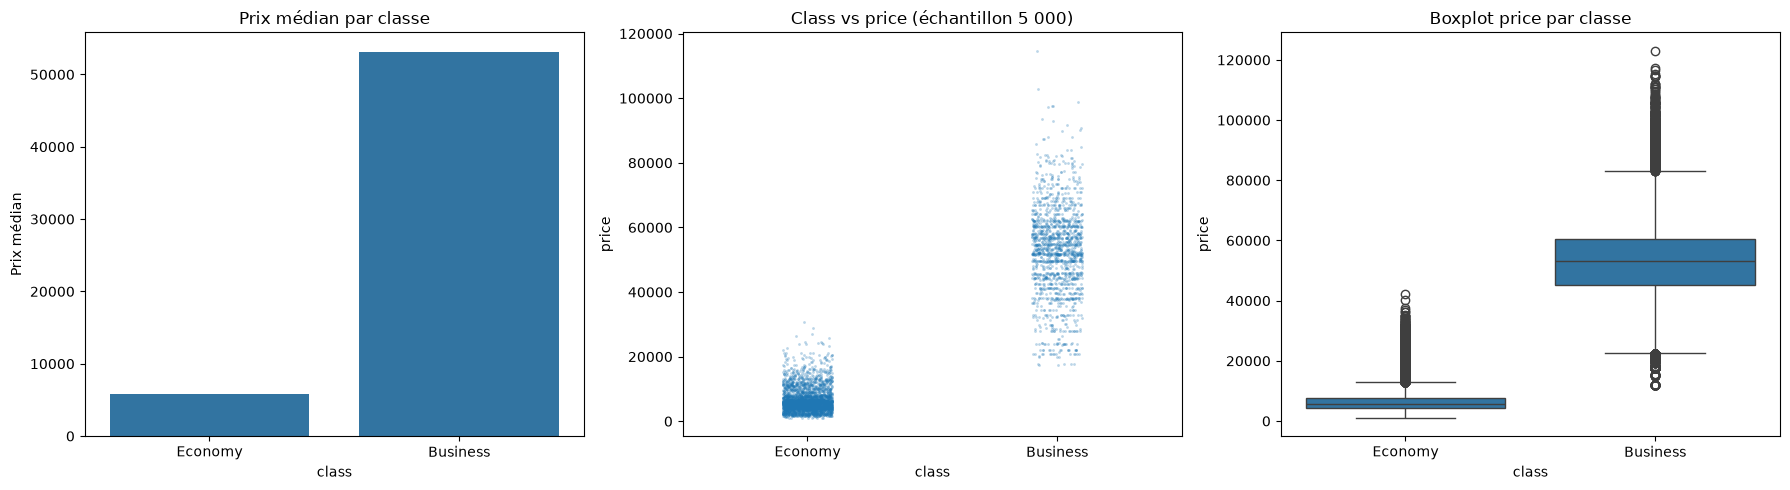

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

class_order = ["Economy", "Business"]
agg = df.groupby("class", observed=True)["price"].median().reset_index()
sample = df.sample(5000, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=agg, x="class", y="price", order=class_order, ax=axes[0])
axes[0].set_title("Prix médian par classe")
axes[0].set_xlabel("class")
axes[0].set_ylabel("Prix médian")

sns.stripplot(data=sample, x="class", y="price", order=class_order, alpha=0.3, s=2, ax=axes[1])
axes[1].set_title("Class vs price (échantillon 5 000)")
axes[1].set_xlabel("class")
axes[1].set_ylabel("price")

sns.boxplot(data=df, x="class", y="price", order=class_order, ax=axes[2])
axes[2].set_title("Boxplot price par classe")
axes[2].set_xlabel("class")
axes[2].set_ylabel("price")

plt.tight_layout()
plt.show()


In [55]:

print("Statistiques de price par classe :")
print(df.groupby("class")["price"].describe()[["mean", "50%", "min", "max"]].round(0))
print("\nEffectifs par classe :")
print(df["class"].value_counts())


Statistiques de price par classe :
             mean      50%      min       max
class                                        
Business  52540.0  53164.0  12000.0  123071.0
Economy    6572.0   5772.0   1105.0   42349.0

Effectifs par classe :
class
Economy     206666
Business     93487
Name: count, dtype: int64


**Observations — Classe et prix (class vs price) :**
- Médiane de price : Economy 5 772 vs Business 53 164 (×9,2).
- Business : moyenne 52 540, min 12 000, max 123 071 ; Economy : moyenne 6 572, min 1 105, max 42 349.
- Chevauchement : les prix Business commencent à 12 000 alors que les prix Economy montent jusqu'à 42 349 (zone commune 12 000–42 349).
- Effectifs : Economy 206 666 (68,9 %), Business 93 487 (31,1 %).


### Créneau horaire de départ et prix (departure_time vs price)


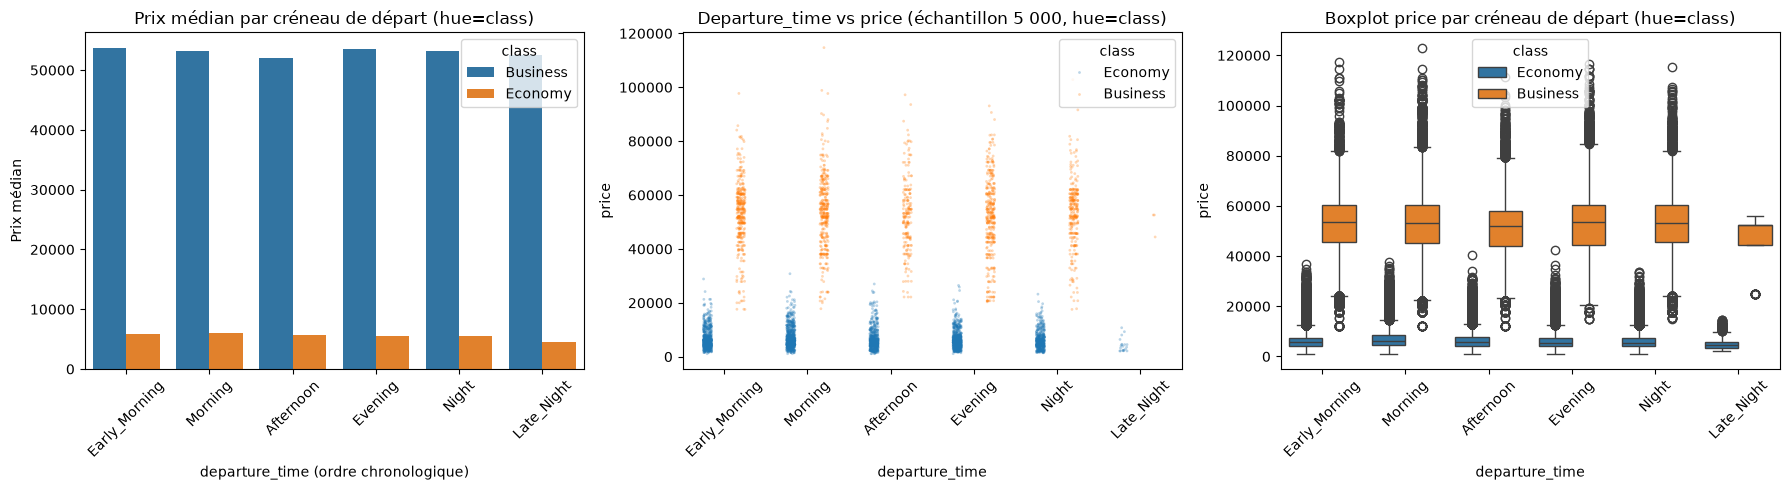

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dep_order = ["Early_Morning", "Morning", "Afternoon", "Evening", "Night", "Late_Night"]
agg = df.groupby(["departure_time", "class"], observed=True)["price"].median().reset_index()
sample = df.sample(5000, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=agg, x="departure_time", y="price", hue="class", order=dep_order, ax=axes[0])
axes[0].set_title("Prix médian par créneau de départ (hue=class)")
axes[0].set_xlabel("departure_time (ordre chronologique)")
axes[0].set_ylabel("Prix médian")
axes[0].tick_params(axis="x", rotation=45)

sns.stripplot(data=sample, x="departure_time", y="price", hue="class", order=dep_order,
              dodge=True, alpha=0.3, s=2, ax=axes[1])
axes[1].set_title("Departure_time vs price (échantillon 5 000, hue=class)")
axes[1].set_xlabel("departure_time")
axes[1].set_ylabel("price")
axes[1].tick_params(axis="x", rotation=45)

sns.boxplot(data=df, x="departure_time", y="price", hue="class", order=dep_order, ax=axes[2])
axes[2].set_title("Boxplot price par créneau de départ (hue=class)")
axes[2].set_xlabel("departure_time")
axes[2].set_ylabel("price")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


In [57]:

print("Médiane et moyenne de price par créneau horaire de départ :")
print(df.groupby("departure_time")["price"].agg(["median", "mean"]).round(0))
print("\nMédiane de price par créneau et par classe :")
print(df.groupby(["departure_time", "class"], observed=True)["price"].median().round(0).unstack())
print("\nPart de Business par créneau :")
print((df.groupby("departure_time")["class"].apply(lambda s: (s == "Business").mean()) * 100).round(1))


Médiane et moyenne de price par créneau horaire de départ :
                median     mean
departure_time                 
Afternoon       6663.0  18179.0
Early_Morning   7212.0  20371.0
Evening         7425.0  21232.0
Late_Night      4499.0   9295.0
Morning         8112.0  21631.0
Night           7813.0  23062.0

Médiane de price par créneau et par classe :
class           Business  Economy
departure_time                   
Afternoon        52063.0   5656.0
Early_Morning    53645.0   5778.0
Evening          53512.0   5507.0
Late_Night       52586.0   4439.0
Morning          53164.0   6067.0
Night            53209.0   5525.0

Part de Business par créneau :
departure_time
Afternoon        26.3
Early_Morning    30.1
Evening          32.1
Late_Night       10.6
Morning          31.4
Night            36.4
Name: class, dtype: float64


**Observations — Créneau horaire de départ et prix (departure_time vs price) :**
- Médiane de price par créneau : Late_Night 4 499 (minimum) vs Morning 8 112 (maximum) ; écart ×1,8.
- Economy : Late_Night 4 439 vs Morning 6 067 (écart 1 628) ; Business : quasi constant de 52 063 (Afternoon) à 53 645 (Early_Morning), écart 1 582.
- Part de Business : Late_Night 10,6 % (la plus faible) vs Night 36,4 % (la plus forte).


### Tendances principales observées

| Relation | Corrélation ou écart mesuré | Sens de la relation avec price |
|---|---|---|
| duration vs price | r = 0,2042 (Economy 0,2884 ; Business 0,2427) ; médiane 0-2h = 3 000 → 16-24h = 12 045 | croissante puis palier (maximum à 16-24h) |
| airline vs price | médiane AirAsia 3 276 → Vistara 15 543 | Air_India et Vistara (avec classe Business) nettement au-dessus des autres |
| stops vs price | médiane zero 4 499 → one 7 959 → two_or_more 8 307 | croissante avec le nombre d'escales |
| days_left vs price | r = −0,09 (Economy −0,56) ; médiane ≤7j 13 944 → 43-49j 5 949 | décroissante à l'approche du départ (portée par Economy) |
| class vs price | médiane Economy 5 772 vs Business 53 164 | Business ≈ ×9 au-dessus d'Economy |
| departure_time vs price | médiane Late_Night 4 499 → Morning 8 112 | variable selon le créneau (max Morning, min Late_Night) |


### MODELISATION


##  Split et Pipeline


### Imports scikit-learn


In [70]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
import numpy as np
from sklearn.dummy import DummyRegressor
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor


### Split : train/test avant tout encodage


In [59]:
df_model = df.copy()
X = df_model.drop(columns=["price"])
y = df_model["price"]
X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=0.2, random_state=42)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("X_train dtypes:\n", X_train.dtypes)


X_train shape: (240122, 11)
X_test shape: (60031, 11)
X_train dtypes:
 Unnamed: 0            int64
airline                 str
flight                  str
source_city             str
departure_time          str
stops                   str
arrival_time            str
destination_city        str
class                   str
duration            float64
days_left             int64
dtype: object


### Pipeline : encodage + LinearRegression


In [60]:
numeric_cols = ["duration", "days_left"]
ordinal_cols = ["stops", "class"]
nominal_cols = ["airline", "source_city", "destination_city",
                "departure_time", "arrival_time"]

preprocess = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("ord", OrdinalEncoder(categories=[["zero", "one", "two_or_more"],
                                        ["Economy", "Business"]]), ordinal_cols),
    ("nom", OneHotEncoder(handle_unknown="ignore"), nominal_cols),
])

pipe = Pipeline([("transformer", preprocess),
                 ("estimator", LinearRegression())])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.4f}")

MAE  : 4500.71
RMSE : 6814.94
R2   : 0.9099


### Dummy Regressor


In [ ]:


pipe_dummy = Pipeline([
    ("transformer", preprocess),
    ("estimator", DummyRegressor(strategy="mean")),
])

pipe_dummy.fit(X_train, y_train)
y_pred_dummy = pipe_dummy.predict(X_test)

mae_dummy = mean_absolute_error(y_test, y_pred_dummy)
rmse_dummy = np.sqrt(mean_squared_error(y_test, y_pred_dummy))
r2_dummy = r2_score(y_test, y_pred_dummy)

print(f"MAE  = {mae_dummy:.1f}")
print(f"RMSE = {rmse_dummy:.1f}")
print(f"R²   = {r2_dummy:.3f}")

MAE  = 19768.7
RMSE = 22704.2
R²   = -0.000


### Ridge


In [ ]:
pipe_ridge = Pipeline([
    ("transformer", preprocess),
    ("estimator", Ridge(alpha=1.0)),
])

pipe_ridge.fit(X_train, y_train)
y_pred_ridge = pipe_ridge.predict(X_test)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"MAE  = {mae_ridge:.1f}")
print(f"RMSE = {rmse_ridge:.1f}")
print(f"R²   = {r2_ridge:.3f}")

MAE  = 4500.7
RMSE = 6814.9
R²   = 0.910


### Random Forest


In [77]:

pipe_rf = Pipeline([
    ("transformer", preprocess),
    ("estimator", RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
])

pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"MAE  = {mae_rf:.1f}")
print(f"RMSE = {rmse_rf:.1f}")
print(f"R²   = {r2_rf:.3f}")

KeyboardInterrupt: 

#### visualisation : prix réel vs prix prédit

In [ ]:
def visualiser_predictions(pipeline, nom_modele, X_test, y_test):
   
    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].scatter(y_test, y_pred, alpha=0.15, s=10, color="steelblue")
    axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                 "r--", linewidth=2, label="Prediction parfaite")
    axes[0].set_xlabel("Prix reel")
    axes[0].set_ylabel("Prix prédit")
    axes[0].set_title(f"{nom_modele} — Prix reel vs predit")
    axes[0].legend()

    # residus = y_test - y_pred
    # axes[1].scatter(y_pred, residus, alpha=0.15, s=10, color="steelblue")
    # axes[1].axhline(0, color="red", linestyle="--", linewidth=2)
    # axes[1].set_xlabel("Prix prdit")
    # axes[1].set_ylabel(" (reel - predit)")
    # axes[1].set_title(f"{nom_modele} — Résidus")

    plt.suptitle(f"{nom_modele} : MAE={mae:.0f}  RMSE={rmse:.0f}  R²={r2:.3f}")
    plt.tight_layout()
    plt.show()

    return {"modele": nom_modele, "MAE": mae, "RMSE": rmse, "R2": r2}

### Tableau comparatif


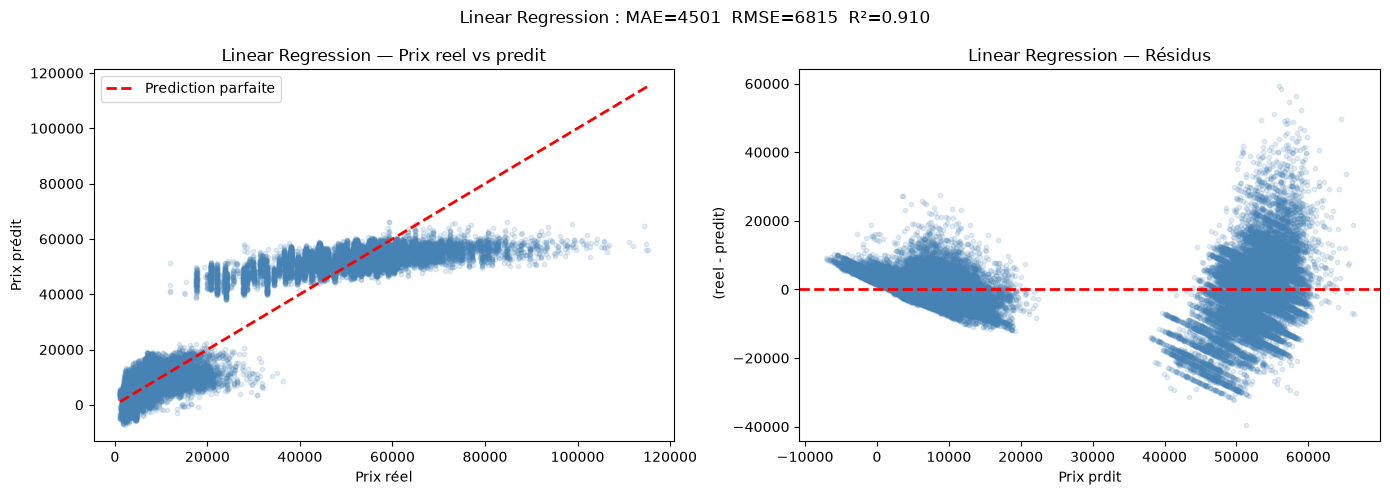

In [80]:
resultats_lr = visualiser_predictions(pipe, "Linear Regression", X_test, y_test)

### Validation croisee (5 folds)


In [ ]:
### 

### Modele final + evaluation sur le test


### Intervalle de confiance 95% sur la MAE


### Export (joblib + métadonnées)
